<a href="https://colab.research.google.com/github/EmilianoCastelan/Procesos-Estocasticos/blob/main/Tutorial_sympy_networkx.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

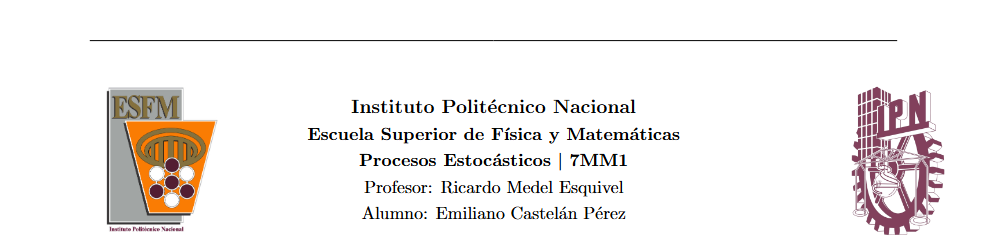

## ¿Qué es Sympy?

SymPy es una librería de Python para matemática simbólica, es decir, permite trabajar con expresiones matemáticas de forma algebraica (con símbolos y variables) en lugar de solo valores numéricos.

Algunos de sus principales usos son:

*   Álgebra simbólica
*   Cálculo diferencial e integral
*   Resolución de ecuaciones
*   Álgebra lineal

En este caso, haremos énfasis en el empleo que se le da en el manejo de matrices y las operaciones que se pueden hacer con estas



## ¿Qué es Networkx?

NetworkX es una biblioteca de Python utilizada para la creación, manipulación y estudio de la estructura, dinámica y funciones de redes complejas . Esta biblioteca es ampliamente utilizada en:

Ciencia de datos (análisis de redes sociales, biológicas, de transporte).
Investigación académica (teoría de grafos, algoritmos).
Ingeniería (optimización de rutas, redes de computadoras).
Características principales:

Soporta grafos dirigidos, no dirigidos, multigrafos y grafos con atributos (pesos, etiquetas, etc.).
Incluye algoritmos clásicos y modernos para análisis de redes.
Fácil integración con otras bibliotecas como Matplotlib, Pandas y NumPy.

**Importamos los elementos que usaremos de las librerías**

In [1]:
import sympy as sp
from sympy.abc import x,y,z
import networkx as nx
import matplotlib.pyplot as plt

**Empezaremos con la biblioteca de Sympy**

La forma en la que introduciremos las componentes de la matriz usando sympy es en filas "[a,b,c....]" y separando una fila de otra con comas

A continuación se mostrara una matriz 3x3

In [2]:
sp.Matrix([[1,2,3],[4,5,6],[7,8,9]])

Matrix([
[1, 2, 3],
[4, 5, 6],
[7, 8, 9]])

Otra forma de introducir una matriz es indicando el número de filas y columnas que tendra la matriz (en ese orden) y despues poniendo los componentes en la forma "[a,b,c....]"


In [3]:
sp.Matrix(3,3,[1,2,3,4,5,6,7,8,9])

Matrix([
[1, 2, 3],
[4, 5, 6],
[7, 8, 9]])

También, podemos agregar variables dentro de la matriz con los simbolos que importamos antes

In [4]:
sp.Matrix([[1,x,3],[x+y,5,6],[7,8,z]])

Matrix([
[    1, x, 3],
[x + y, 5, 6],
[    7, 8, z]])

A estos símbolos, también les podemos dar valores específicos

In [5]:
sp.Matrix([[1,x,3],[x+y,5,6],[7,8,z]]).subs(x,12)

Matrix([
[     1, 12, 3],
[y + 12,  5, 6],
[     7,  8, z]])

Así obtenemos una entrada especifica de una matriz, primero definimos una matriz y despues obtenemos la entrada de la forma en que se muestra

In [6]:
A = sp.Matrix([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])

entrada = A[1,2]
print(entrada)

6


Para obtener una fila y una columna

In [9]:
fila = A.row(1)
print("La fila seleccionada es:",fila)

columna = A.col(2)
print("La columna seleccionada es:",columna)

La fila seleccionada es: Matrix([[4, 5, 6]])
La columna seleccionada es: Matrix([[3], [6], [9]])


Para multiplicar matrices primero debemos definir otra matriz y despues realizamos el producto, teniendo en cuenta que sean dimensiones compatibles para realizar el producto

In [11]:
B = sp.Matrix([
    [1,0,2],
    [0,1,0],
    [2,0,1]
])

C = A * B
print(C)

Matrix([[7, 2, 5], [16, 5, 14], [25, 8, 23]])


Elevar una matriz a una potencia

In [13]:
A2 = A**2
A3 = A**3
print(A2)
print(A3)

Matrix([[30, 36, 42], [66, 81, 96], [102, 126, 150]])
Matrix([[468, 576, 684], [1062, 1305, 1548], [1656, 2034, 2412]])


Para multiplicar vectores por una matriz es importante el orden tomando en cuenta si es un vector nx1 o 1xn

In [15]:
v = sp.Matrix([
    [1],
    [2],
    [3]
])

u = sp.Matrix([[1,2,3]])

resultado = A * v
resultado2 = u * A
print(resultado)
print(resultado2)

Matrix([[14], [32], [50]])
Matrix([[30, 36, 42]])


**Valores propios**

Para calcular los valores propios de una matriz se usara el comando eigenvals

In [16]:
D = sp.Matrix([
    [2,0],
    [0,3]
])

print(D.eigenvals())

{2: 1, 3: 1}


La interpretación de los resultados es:

$\lambda _1=2$, $\lambda _2=3$

Y para los vectores propios se usara eigenvects

In [17]:
E = sp.Matrix([
    [2,0],
    [0,3]
])

E.eigenvects()

[(2,
  1,
  [Matrix([
   [1],
   [0]])]),
 (3,
  1,
  [Matrix([
   [0],
   [1]])])]

Su interpretación es:

$\lambda =2$, v=(1  0)

$\lambda =3$, u=(0  1)

De una forma más practica, se pueden calcular como

In [18]:
for val, mult, vect in E.eigenvects():
    print("Valor propio:", val)
    print("Vector propio:", vect)

Valor propio: 2
Vector propio: [Matrix([
[1],
[0]])]
Valor propio: 3
Vector propio: [Matrix([
[0],
[1]])]


**Ahora, la biblioteca Networkx**

Empezaremos creando un grafo vacio

In [ ]:
# Primero creamos un grafo
G = nx.Graph()

# Añadimos los nodos que deseamos

G.add_node("A") #De esta forma se agrega el primer nodo

G.add_nodes_from(["B", "C", "D","E","F"])

# Añadimos las aristas o ramas con los valores que deseamos
G.add_edge("O", "A",capacity=5)
G.add_edge("O", "B",capacity=2)
G.add_edge("O", "C",capacity=7)
G.add_edge("A", "B",capacity=3)
G.add_edge("A", "D",capacity=8)
G.add_edge("B", "C",capacity=1)
G.add_edge("B", "D",capacity=4)
G.add_edge("D", "E",capacity=3)
G.add_edge("E", "B",capacity=3)
G.add_edge("C", "D",capacity=2)
G.add_edge("C", "E",capacity=3)
G.add_edge("D", "E",capacity=6)
G.add_edge("E", "F",capacity=1)
G.add_edge("D", "F",capacity=7)

Ahora, hacemos que se ilustre la grafica

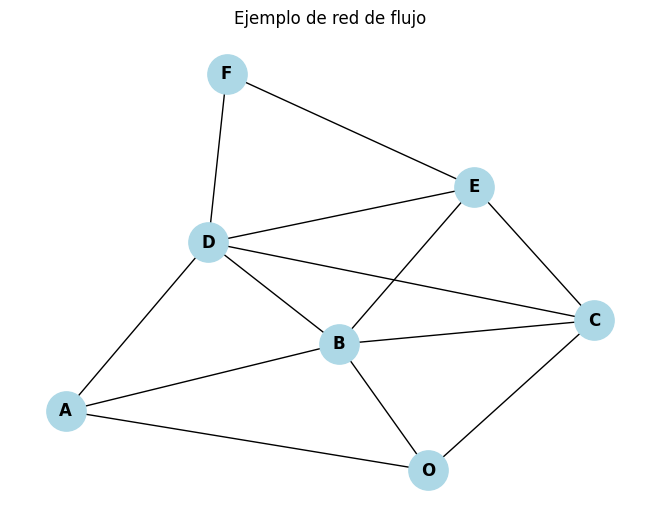

In [ ]:
nx.draw(G, with_labels=True, node_color='lightblue', node_size=800, font_weight='bold')
plt.title("Ejemplo de red de flujo")
plt.show()

In [ ]:
H = nx.path_graph(10)
G.add_nodes_from(H)

**Analisis de la red de flujo**

*a) Número de nodos y aristas*


In [ ]:
print("Nodos:", G.nodes())
print("Ramas:", G.edges())
print("Número de nodos:", G.number_of_nodes())
print("Número de ramas:", G.number_of_edges())


Nodos: ['A', 'B', 'C', 'D', 'E', 'F', 'O']
Ramas: [('A', 'O'), ('A', 'B'), ('A', 'D'), ('B', 'O'), ('B', 'C'), ('B', 'D'), ('B', 'E'), ('C', 'O'), ('C', 'D'), ('C', 'E'), ('D', 'E'), ('D', 'F'), ('E', 'F')]
Número de nodos: 7
Número de ramas: 13


*b) Grado de un nodo (conexiones que tiene)*

In [ ]:
print("Grado del nodo O:", G.degree["O"])
print("Grado del nodo A:", G.degree["A"])
print("Grado del nodo B:", G.degree["B"])
print("Grado del nodo C:", G.degree["C"])
print("Grado del nodo D:", G.degree["D"])
print("Grado del nodo E:", G.degree["E"])
print("Grado del nodo F:", G.degree["F"])

Grado del nodo O: 3
Grado del nodo A: 3
Grado del nodo B: 5
Grado del nodo C: 4
Grado del nodo D: 5
Grado del nodo E: 4
Grado del nodo F: 2


*c) Vecinos de un nodo*

In [ ]:
print("Vecinos del nodo O:", list(G.neighbors("O")))
print("Vecinos del nodo A:", list(G.neighbors("A")))
print("Vecinos del nodo B:", list(G.neighbors("B")))
print("Vecinos del nodo C:", list(G.neighbors("C")))
print("Vecinos del nodo D:", list(G.neighbors("D")))
print("Vecinos del nodo E:", list(G.neighbors("E")))
print("Vecinos del nodo F:", list(G.neighbors("F")))


Vecinos del nodo O: ['A', 'B', 'C']
Vecinos del nodo A: ['O', 'B', 'D']
Vecinos del nodo B: ['O', 'A', 'C', 'D', 'E']
Vecinos del nodo C: ['O', 'B', 'D', 'E']
Vecinos del nodo D: ['A', 'B', 'E', 'C', 'F']
Vecinos del nodo E: ['D', 'B', 'C', 'F']
Vecinos del nodo F: ['E', 'D']


*d) Camino más corto entre dos nodos*

In [ ]:
print("Camino más corto de O y F:", nx.shortest_path(G, source="O", target="F"))

Camino más corto de O y F: ['O', 'B', 'E', 'F']


 **Gráfico Dirigido**

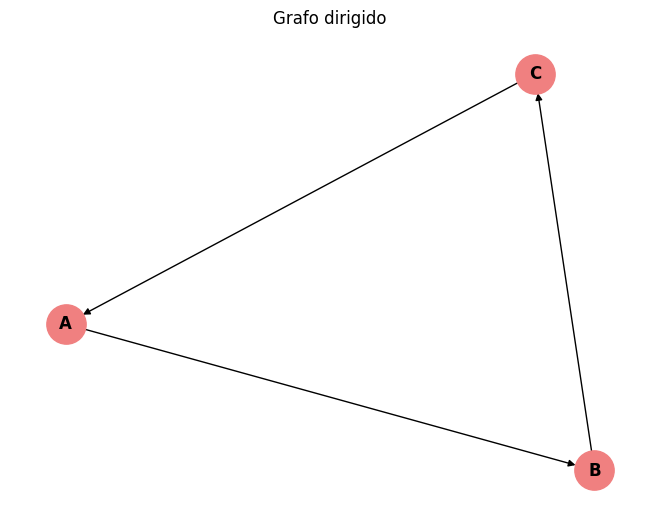

In [ ]:
D = nx.DiGraph()
D.add_edges_from([("A", "B"), ("B", "C"), ("C", "A")])
nx.draw(D, with_labels=True, node_color='lightcoral', node_size=800, font_weight='bold')
plt.title("Grafo dirigido")
plt.show()


**Bordes**

*Acceder a las aristas y sus atributos
 Copiar*

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Tu grafo
G = nx.Graph()
G.add_nodes_from(["A", "B", "C", "D", "E", "F", "O"])
G.add_edge("O", "A", capacity=5)
G.add_edge("O", "B", capacity=2)
G.add_edge("O", "C", capacity=7)
G.add_edge("A", "B", capacity=3)
G.add_edge("A", "D", capacity=8)
G.add_edge("B", "C", capacity=1)
G.add_edge("B", "D", capacity=4)
G.add_edge("D", "E", capacity=3)
G.add_edge("E", "B", capacity=3)
G.add_edge("C", "D", capacity=2)
G.add_edge("C", "E", capacity=3)
G.add_edge("D", "E", capacity=6)
G.add_edge("E", "F", capacity=1)
G.add_edge("D", "F", capacity=7)

# Mostrar todas las aristas con sus capacidades
print("Aristas con capacidades:")
for u, v, data in G.edges(data=True):
    print(f"{u} -- {v}: {data}")



Aristas con capacidades:
A -- O: {'capacity': 5}
A -- B: {'capacity': 3}
A -- D: {'capacity': 8}
B -- O: {'capacity': 2}
B -- C: {'capacity': 1}
B -- D: {'capacity': 4}
B -- E: {'capacity': 3}
C -- O: {'capacity': 7}
C -- D: {'capacity': 2}
C -- E: {'capacity': 3}
D -- E: {'capacity': 6}
D -- F: {'capacity': 7}
E -- F: {'capacity': 1}


**Eliminar elementos del Grafo**

*Eliminar un nodo (ej: "E")*

Al eliminarun nodo, en este caso el "E", también se eliminan todas sus aristas

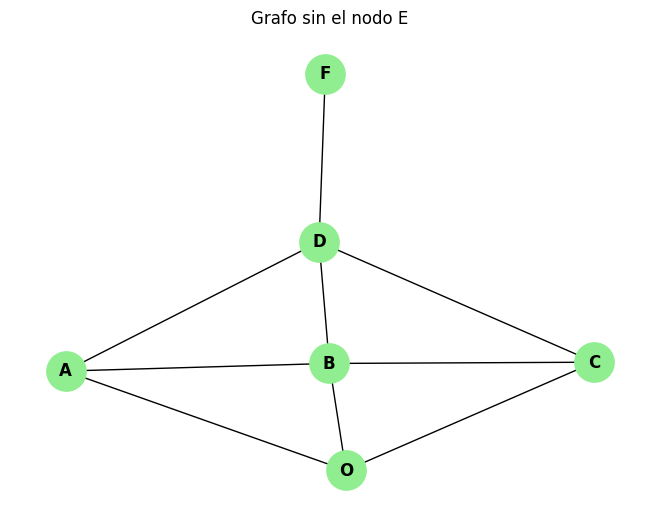

In [ ]:
G.remove_node("E")
nx.draw(G, with_labels=True, node_color='lightgreen', node_size=800, font_weight='bold')
plt.title("Grafo sin el nodo E")
plt.show()


*Eliminar una arista (ej: "O" -- "B")*

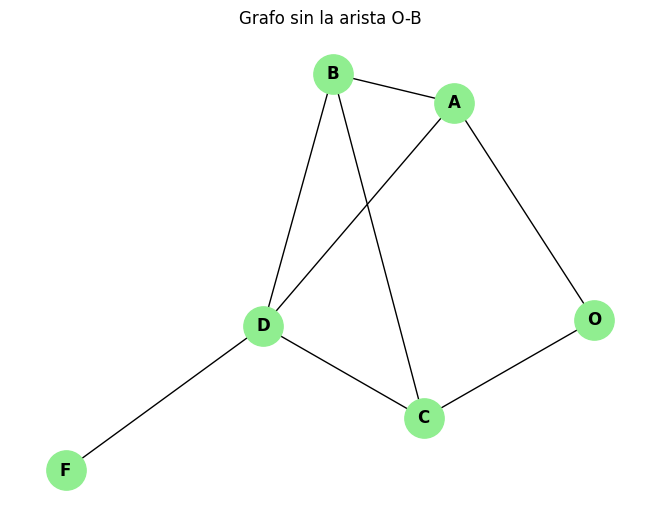

In [ ]:
G.remove_edge("O", "B")
nx.draw(G, with_labels=True, node_color='lightgreen', node_size=800, font_weight='bold')
plt.title("Grafo sin la arista O-B")
plt.show()


**Constructores de Grafos**


El flujo máximo de O a F es: 8

Detalle del flujo en cada arista:
O -> A: 3/5
O -> C: 5/7
A -> D: 3/8
B -> D: 2/4
C -> D: 2/2
C -> E: 3/3
D -> F: 7/7
E -> B: 2/3
E -> F: 1/1


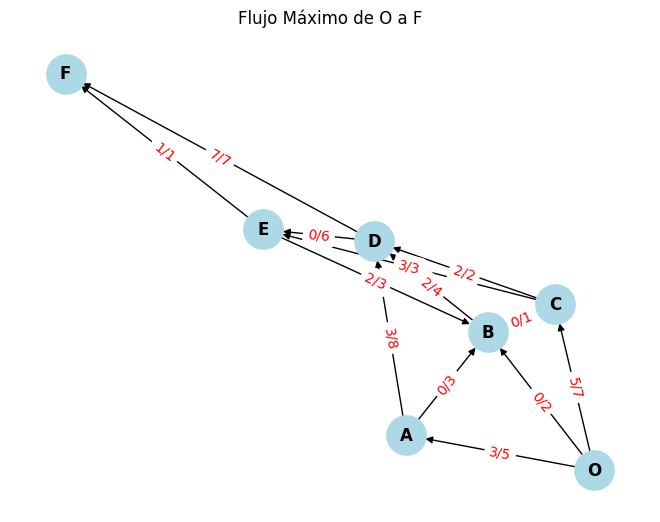

In [ ]:
G_dirigido = nx.DiGraph()
G_dirigido.add_edge("O", "A", capacity=5)
G_dirigido.add_edge("O", "B", capacity=2)
G_dirigido.add_edge("O", "C", capacity=7)
G_dirigido.add_edge("A", "B", capacity=3)
G_dirigido.add_edge("A", "D", capacity=8)
G_dirigido.add_edge("B", "C", capacity=1)
G_dirigido.add_edge("B", "D", capacity=4)
G_dirigido.add_edge("D", "E", capacity=3)
G_dirigido.add_edge("E", "B", capacity=3)
G_dirigido.add_edge("C", "D", capacity=2)
G_dirigido.add_edge("C", "E", capacity=3)
G_dirigido.add_edge("D", "E", capacity=6)
G_dirigido.add_edge("E", "F", capacity=1)
G_dirigido.add_edge("D", "F", capacity=7)

# Calcular el flujo máximo desde "O" hasta "F"
flujo_maximo, flujo_dict = nx.maximum_flow(G_dirigido, "O", "F")
print(f"El flujo máximo de O a F es: {flujo_maximo}")

# Imprimir el flujo que pasa por cada arista
print("\nDetalle del flujo en cada arista:")
for origen in flujo_dict:
    for destino, flujo in flujo_dict[origen].items():
        if flujo > 0:  # Solo imprimir aristas con flujo
            capacidad = G_dirigido[origen][destino]['capacity']
            print(f"{origen} -> {destino}: {flujo}/{capacidad}")

# Visualizar el grafo con los flujos
pos = nx.spring_layout(G_dirigido)
nx.draw(G_dirigido, pos, with_labels=True, node_color='lightblue', node_size=800, font_weight='bold')
nx.draw_networkx_edge_labels(
    G_dirigido, pos,
    edge_labels={(u, v): f"{flujo_dict[u].get(v, 0)}/{G_dirigido[u][v]['capacity']}" for u, v in G_dirigido.edges()},
    font_color='red'
)
plt.title("Flujo Máximo de O a F")
plt.show()


**Ruta más corta**

In [ ]:
ruta_corta = nx.dijkstra_path(G, source="O", target="F", weight='capacity')
print("Ruta más corta de O a F:", ruta_corta)
print("Distancia total:", nx.dijkstra_path_length(G, source="O", target="F", weight='capacity'))


Ruta más corta de O a F: ['O', 'C', 'D', 'F']
Distancia total: 16


*Árbol de expansión mínima*

Aristas del MST:
A -- O: 5
A -- B: 3
A -- D: 8
B -- C: 1
D -- F: 7


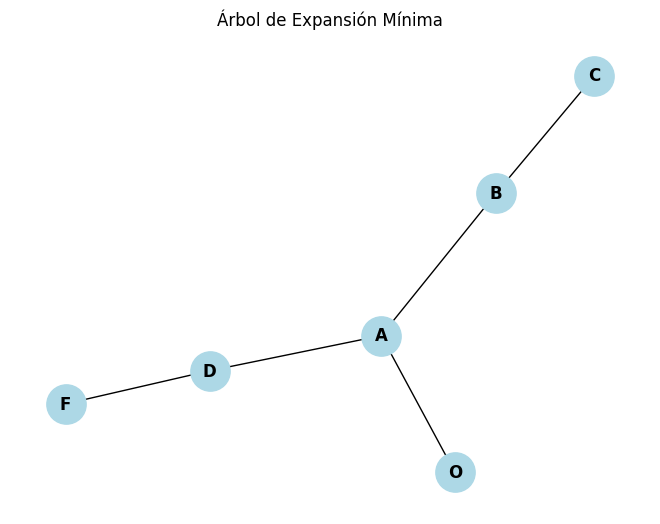

In [ ]:
mst = nx.minimum_spanning_tree(G)
print("Aristas del MST:")
for u, v, data in mst.edges(data=True):
    print(f"{u} -- {v}: {data['capacity']}")

# Visualizar el MST
nx.draw(mst, with_labels=True, node_color='lightblue', node_size=800, font_weight='bold')
plt.title("Árbol de Expansión Mínima")
plt.show()
